<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [143]:
# Your code here
df = pd.read_csv('./data/College.csv')
df.head()
df = df.rename(columns={'Unnamed: 0': 'College'})
df.head()


,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [144]:
# Your code here
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())


(777, 19)
College            str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object
College        0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64


#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [145]:
# Your code here
df['PhD'].value_counts()

PhD
?      29
77     26
73     24
90     22
71     21
       ..
32      1
14      1
103     1
26      1
16      1
Name: count, Length: 78, dtype: int64

In [146]:
# Convert the PhD column to numeric; any value that can't be converted (like '?') becomes NaN
df['PhD'] = pd.to_numeric(df['PhD'], errors='coerce')

# Any PhD percentage above 100 is impossible, so treat it as missing data too
df.loc[df['PhD'] > 100, 'PhD'] = np.nan

# Fill all missing values with the median
df['PhD'] = df['PhD'].fillna(df['PhD'].median())


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [147]:
df['Grad.Rate'].sort_values(ascending=False)

95     118
522    100
126    100
238    100
251    100
      ... 
113     21
66      18
384     15
4       15
585     10
Name: Grad.Rate, Length: 777, dtype: int64

In [148]:
# Your code here
# Any graduation rate above 100 is a data entry error, so treat it as missing
df.loc[df['Grad.Rate'] > 100, 'Grad.Rate'] = np.nan

# Fill the missing value with the median graduation rate
df['Grad.Rate'] = df['Grad.Rate'].fillna(df['Grad.Rate'].median())

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [149]:
%%writefile myutils.py

import pandas as pd
import numpy as np

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 

    results = []
    
    # select only numeric columns
    numeric_cols = df.select_dtypes(include=np.number).columns


    for col in numeric_cols:
        
        # Skip binary indicators (0/1) or columns ending with '_id'
        if 'id' in str(col).lower() or df[col].nunique() <= 2:
            continue

        skew_val = df[col].skew()
        min_val = df[col].min()

        # classify degree and direction based on Table 1
        if skew_val < -1:
            degree, direction = 'Highly Skewed', 'Left'
        elif -1 <= skew_val < -0.5:
            degree, direction = 'Moderately Skewed', 'Left'
        elif -0.5 <= skew_val <= 0.5:
            degree, direction = 'Normal', 'Symmetrical'
        elif 0.5 < skew_val <= 1:
            degree, direction = 'Moderately Skewed', 'Right'
        else:
            degree, direction = 'Highly Skewed', 'Right'

        # recommend transformation based on Table 2
        if degree == 'Normal':
            recommendation = 'None'
        elif min_val < 0:
            recommendation = 'Yeo-Johnson'
        elif min_val == 0:
            recommendation = 'Log Plus One'
        else:
            recommendation = 'Box-Cox'

        results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommendation
        })

    return pd.DataFrame(results)

        


Overwriting myutils.py


In [150]:
# Now import the function from myutils
from myutils import skew_calc

In [151]:
from scipy import stats
from sklearn.preprocessing import PowerTransformer

def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    
    # only work on columns that actually need a transformation
    skewed_cols = skew_table[skew_table['Recommended Transformation'] != 'None']

    for _, row in skewed_cols.iterrows():
        col = row['Feature']
        method = row['Recommended Transformation']
        original = df[col]

        # apply the recommended transformation
        if method == 'Log Plus One':
            transformed = np.log1p(original)
        elif method == 'Box-Cox':
            transformed, _ = stats.boxcox(original)
        elif method == 'Yeo-Johnson':
            pt = PowerTransformer(method='yeo-johnson')
            transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()

        # plot before and after side by side
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(original, kde=True, ax=axes[0])
        axes[0].set_title(f'{col} - Before (Skew: {original.skew():.2f})')

        sns.histplot(transformed, kde=True, ax=axes[1])
        axes[1].set_title(f'{col} - After {method} (Skew: {pd.Series(transformed).skew():.2f})')

        plt.tight_layout()
        plt.show()    

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [152]:
# Your code here
skew_table = skew_calc(df)
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Right,Box-Cox
1,Accept,3.417727,Highly Skewed,Right,Box-Cox
2,Enroll,2.690465,Highly Skewed,Right,Box-Cox
3,Top10perc,1.413217,Highly Skewed,Right,Box-Cox
4,Top25perc,0.259340,Normal,Symmetrical,None
5,F.Undergrad,2.610458,Highly Skewed,Right,Box-Cox
6,P.Undergrad,5.692353,Highly Skewed,Right,Box-Cox
7,Outstate,0.509278,Moderately Skewed,Right,Box-Cox
8,Room.Board,0.477356,Normal,Symmetrical,None
9,Books,3.485025,Highly Skewed,Right,Box-Cox


In [153]:
# Your code here

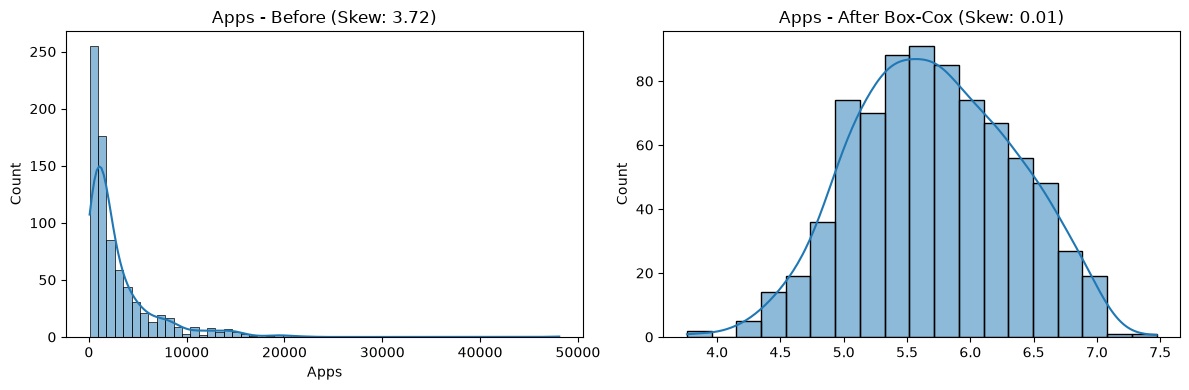

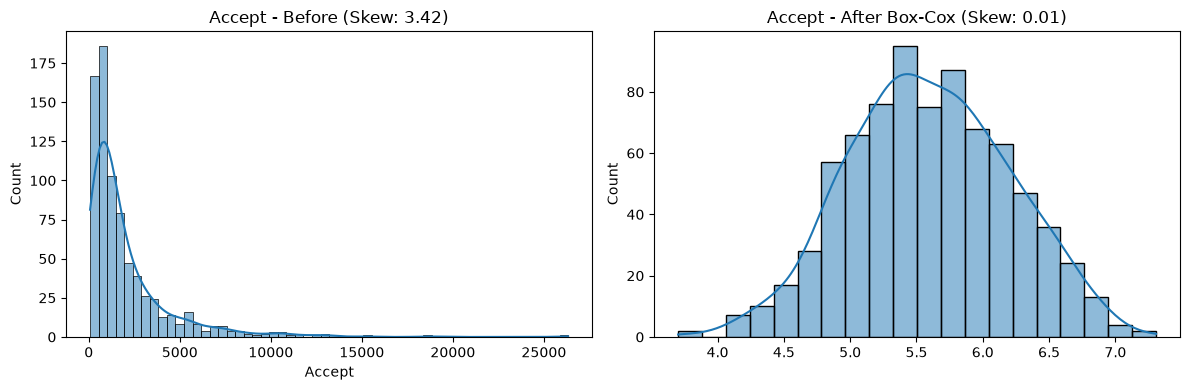

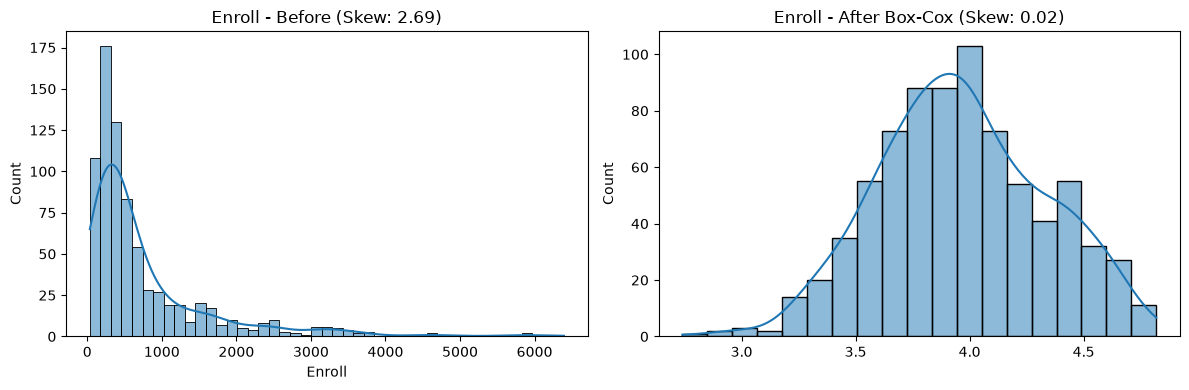

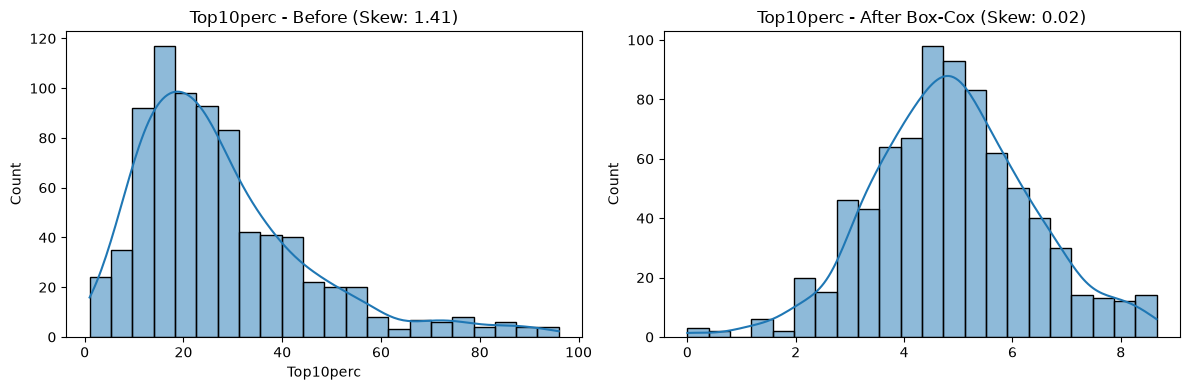

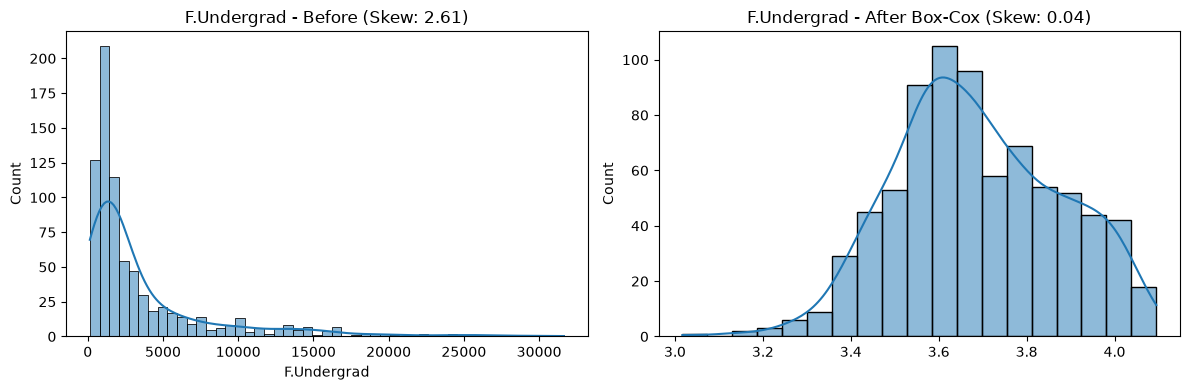

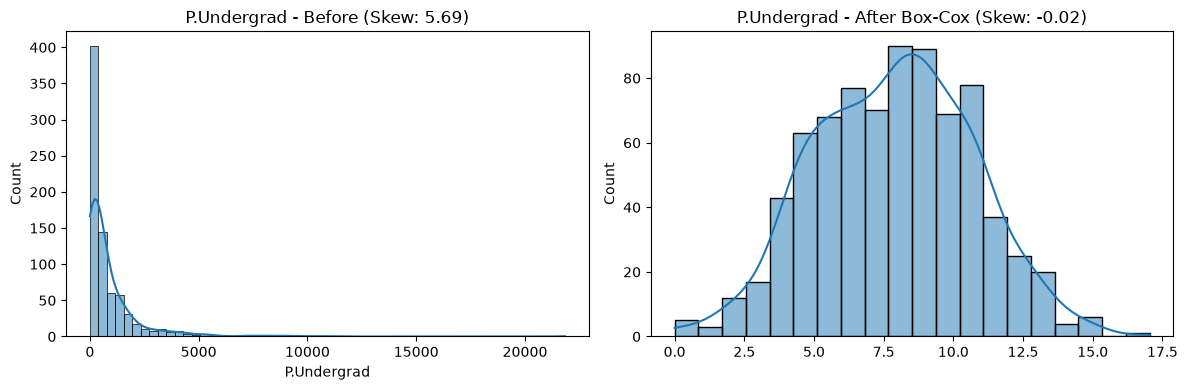

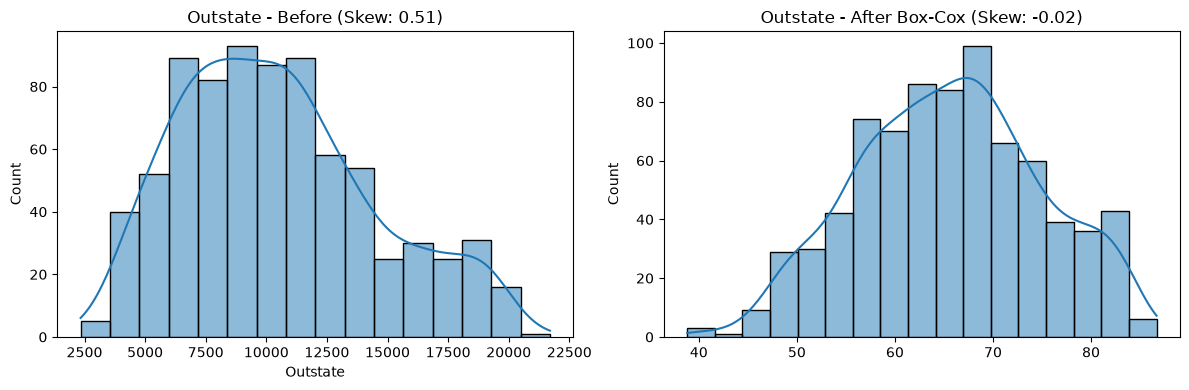

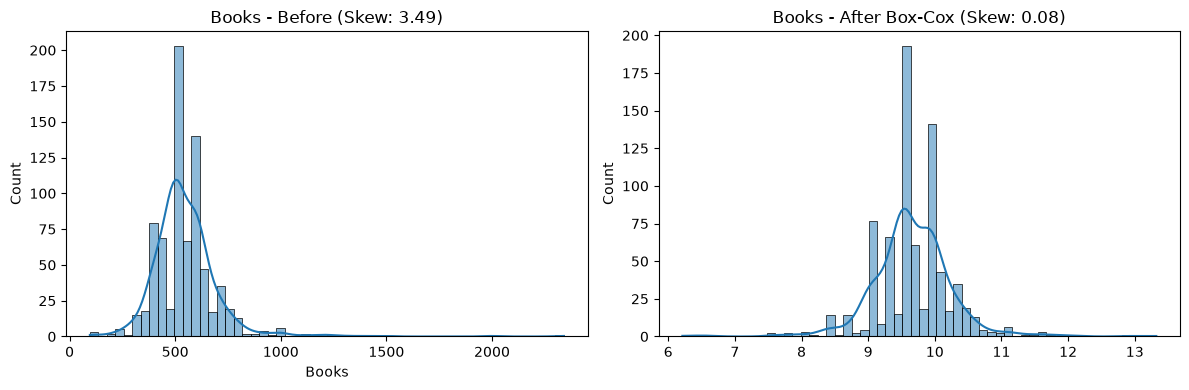

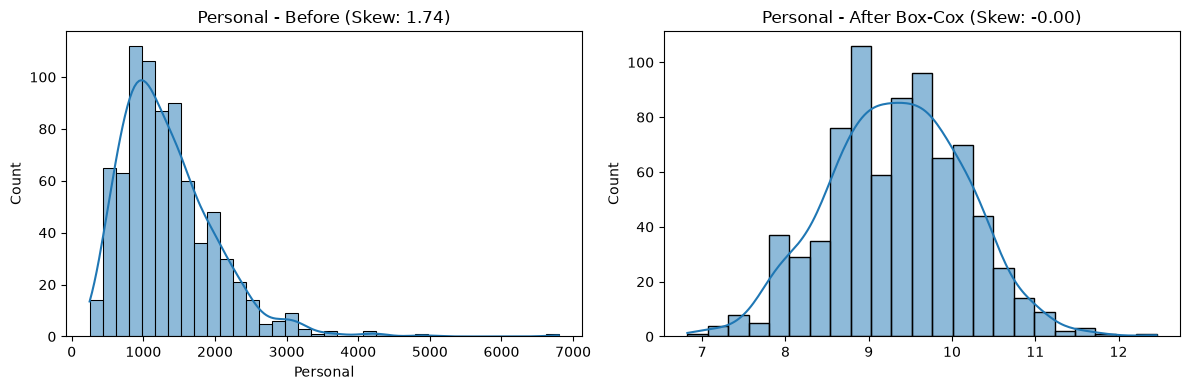

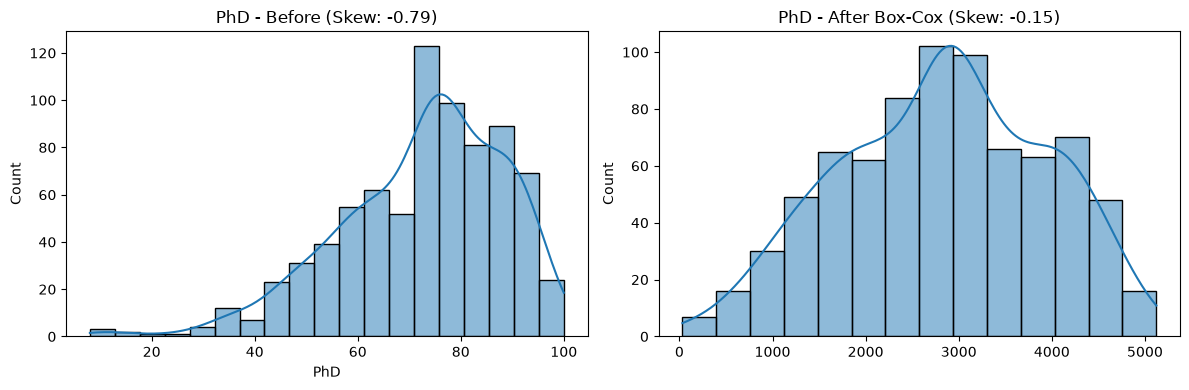

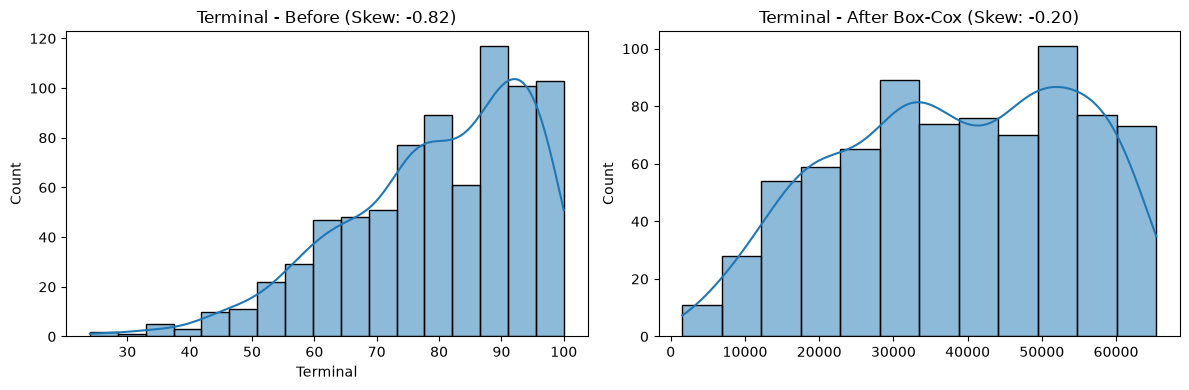

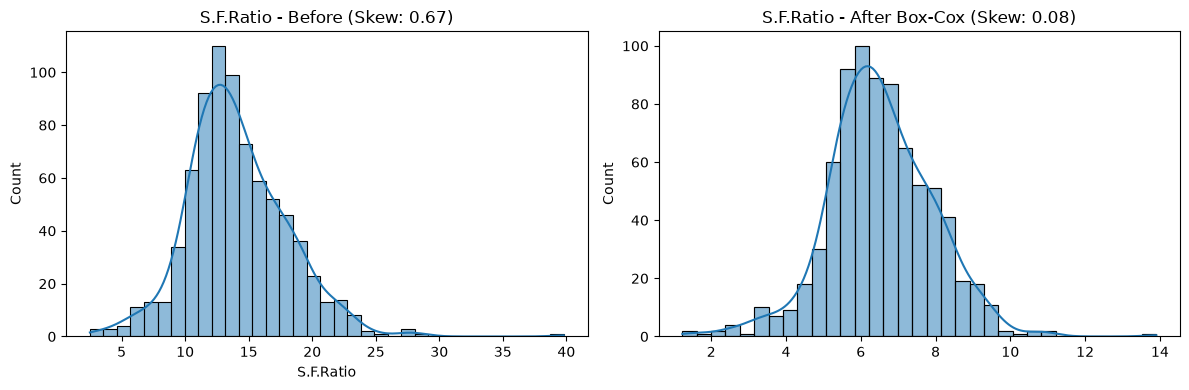

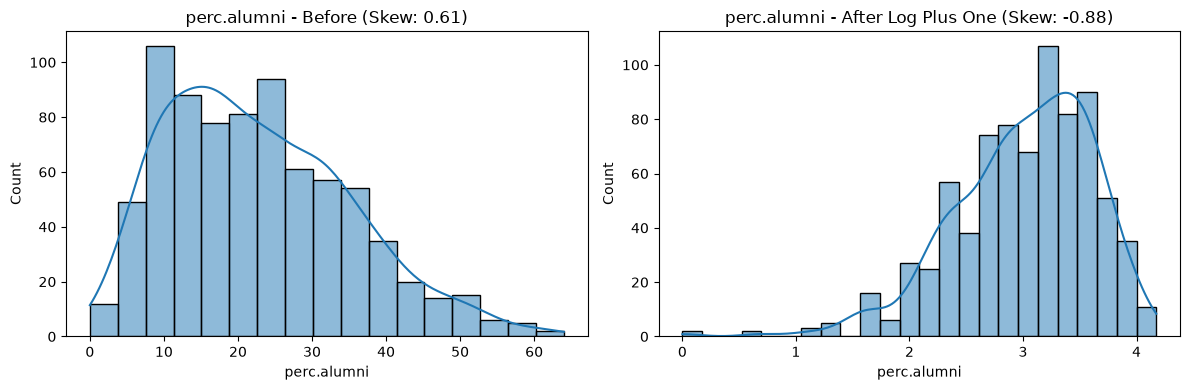

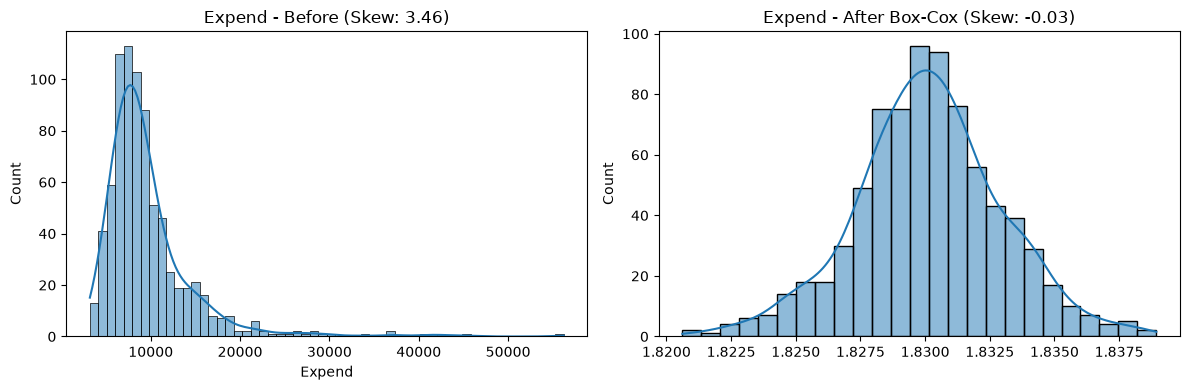

In [154]:
# Your code here
plot_transformations(df, skew_table)

In [155]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [156]:
trans_cols = []
# Your code here

for _, row in skew_table.iterrows():
    col = row['Feature']
    transformation = row['Recommended Transformation']

    if transformation == 'None':
        continue

    new_col = f'{col}_transformed'

    if transformation == 'Log Plus One':
        df[new_col] = np.log1p(df[col])
    elif transformation == 'Box-Cox':
        df[new_col], _ = stats.boxcox(df[col])
    elif transformation == 'Yeo-Johnson':
        df[new_col], _ = stats.yeojohnson(df[col])

    trans_cols.append(new_col)

df.head()


,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,3.769302,8.713915,59.142209,9.288880,10.374877,2504.239962,34148.774234,7.965493,2.564949,1.828730
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,3.756515,10.316290,70.781897,10.448462,9.706972,427.169553,2801.807925,5.909038,2.833213,1.831689
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,3.568664,5.815935,68.600055,9.032160,9.276476,1433.028797,22055.928365,6.170678,3.433987,1.830396
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,3.401005,5.119856,72.157160,9.288880,8.798545,4333.028101,60412.083923,4.059557,3.637586,1.835020
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,3.202743,9.631371,59.483775,10.600468,9.706972,2953.457225,27695.561321,5.795125,1.098612,1.831929


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [157]:
# Your code here 
df['Accept_Rate'] = df['Accept'] / df['Apps']
df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed,Accept_Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,8.713915,59.142209,9.288880,10.374877,2504.239962,34148.774234,7.965493,2.564949,1.828730,0.742169
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,10.316290,70.781897,10.448462,9.706972,427.169553,2801.807925,5.909038,2.833213,1.831689,0.880146
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,5.815935,68.600055,9.032160,9.276476,1433.028797,22055.928365,6.170678,3.433987,1.830396,0.768207
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,5.119856,72.157160,9.288880,8.798545,4333.028101,60412.083923,4.059557,3.637586,1.835020,0.836930
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,9.631371,59.483775,10.600468,9.706972,2953.457225,27695.561321,5.795125,1.098612,1.831929,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [158]:
# Your code here 
df['Outstate_Tier']=pd.cut(
    df['Outstate'],
    bins=[0, 8000, 15000, df['Outstate'].max()],
    labels=['Low', 'Medium', 'High']
)
df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed,Accept_Rate,Outstate_Tier
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,59.142209,9.288880,10.374877,2504.239962,34148.774234,7.965493,2.564949,1.828730,0.742169,Low
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,70.781897,10.448462,9.706972,427.169553,2801.807925,5.909038,2.833213,1.831689,0.880146,Medium
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,68.600055,9.032160,9.276476,1433.028797,22055.928365,6.170678,3.433987,1.830396,0.768207,Medium
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,72.157160,9.288880,8.798545,4333.028101,60412.083923,4.059557,3.637586,1.835020,0.836930,Medium
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,59.483775,10.600468,9.706972,2953.457225,27695.561321,5.795125,1.098612,1.831929,0.756477,Low


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [159]:
# Your code here 
tier_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

df['Outstate_Tier_encoded'] = df['Outstate_Tier'].map(tier_mapping)
df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed,Accept_Rate,Outstate_Tier,Outstate_Tier_encoded
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,9.288880,10.374877,2504.239962,34148.774234,7.965493,2.564949,1.828730,0.742169,Low,0
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,10.448462,9.706972,427.169553,2801.807925,5.909038,2.833213,1.831689,0.880146,Medium,1
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,9.032160,9.276476,1433.028797,22055.928365,6.170678,3.433987,1.830396,0.768207,Medium,1
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,9.288880,8.798545,4333.028101,60412.083923,4.059557,3.637586,1.835020,0.836930,Medium,1
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,10.600468,9.706972,2953.457225,27695.561321,5.795125,1.098612,1.831929,0.756477,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [160]:
# Your code here 
df['Private_encoded'] = df['Private'].map({'Yes': 1, 'No': 0})


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [161]:
cols_to_scale = []

# Your code here 
cols_to_scale = trans_cols + ['Outstate_Tier_encoded', 'Private_encoded', 'Accept_Rate']
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[cols_to_scale])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=[col + '_scaled' for col in cols_to_scale],
    index=df.index
)

df = pd.concat([df, scaled_df], axis=1)

df.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books_transformed_scaled,Personal_transformed_scaled,PhD_transformed_scaled,Terminal_transformed_scaled,S.F.Ratio_transformed_scaled,perc.alumni_transformed_scaled,Expend_transformed_scaled,Outstate_Tier_encoded_scaled,Private_encoded_scaled,Accept_Rate_scaled
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,-0.614254,1.271398,-0.290438,-0.282374,1.017946,-0.722701,-0.491183,-1.267912,0.612553,-0.032372
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,1.302365,0.456551,-2.177364,-2.248129,-0.435083,-0.284489,0.552362,0.247730,0.612553,0.906193
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,-1.038575,-0.068655,-1.263585,-1.040711,-0.250216,0.696881,0.096393,0.247730,0.612553,0.144750
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,-0.614254,-0.651734,1.370935,1.364588,-1.741872,1.029462,1.726997,0.247730,0.612553,0.612225
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,1.553608,0.456551,0.117656,-0.687052,-0.515571,-3.117978,0.637044,-1.267912,0.612553,0.064955


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

In [162]:
college_updated= df.copy()

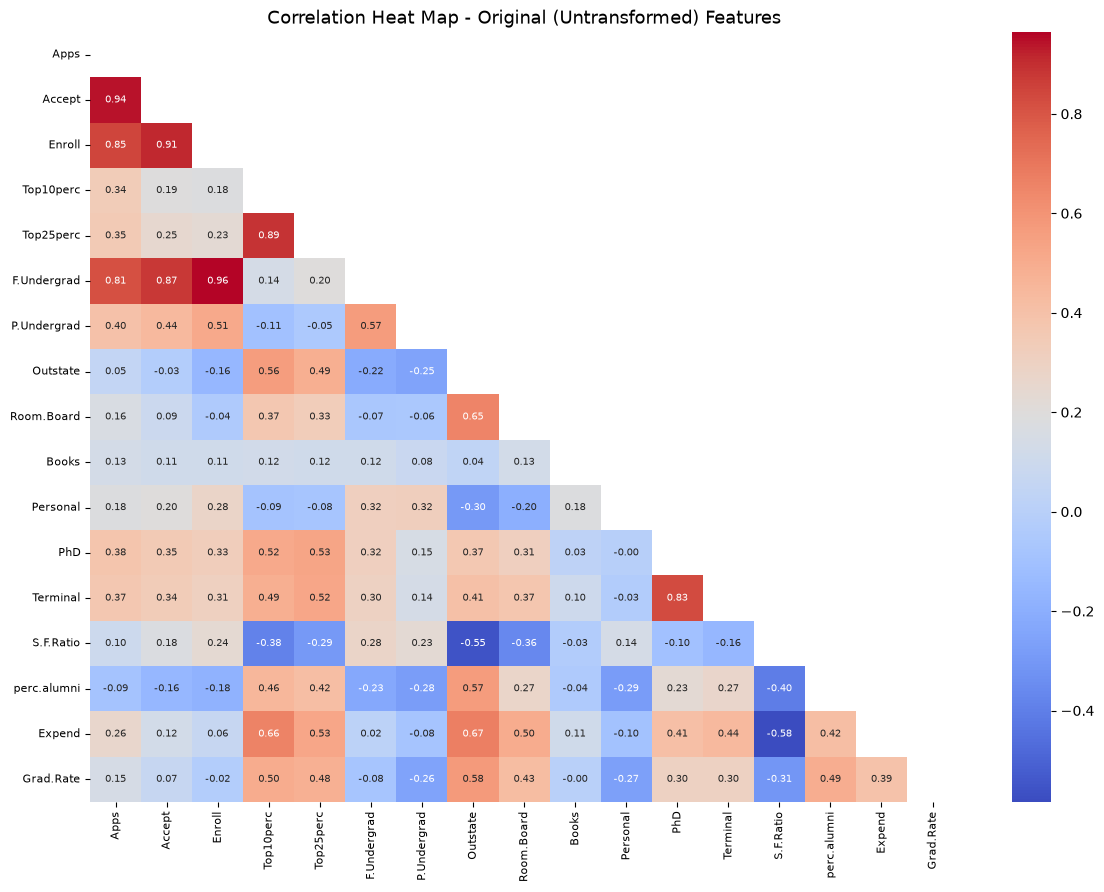

In [163]:
# Your code here

# 1. Heatmap of the original (untransformed) numeric columns
original_cols = ['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad',
                  'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD',
                  'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate']

corr_original = df[original_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_original, annot=True, mask=np.triu(corr_original), annot_kws={"size": 7}, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heat Map - Original (Untransformed) Features', size=13)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.show()

In [164]:
# 1. Define your target column and correlation threshold
target = 'Grad.Rate'  # Replace with your target column name if different
threshold = 0.8

# 2. Get absolute correlation matrix of original numeric columns from college_updated
corr = college_updated[original_cols].corr().abs()

# 3. Get a list of features (excluding the target column itself)
cols = [c for c in corr.columns if c != target]

to_drop = set()

# 4. Loop through every unique pair of features
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]

        # Check if the feature pair is highly correlated
        if corr.loc[col1, col2] >= threshold:
            # Check how each feature correlates with the target
            corr1 = corr.loc[col1, target]
            corr2 = corr.loc[col2, target]

            # Keep the one with higher target correlation, mark the lower one to drop
            if corr1 >= corr2:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

# 5. Print the columns you should remove
print("Columns to drop:", list(to_drop))

# 6. Drop those redundant columns from your college_updated dataframe
college_updated = college_updated.drop(columns=list(to_drop))

Columns to drop: ['Terminal', 'F.Undergrad', 'Enroll', 'Top25perc', 'Accept']


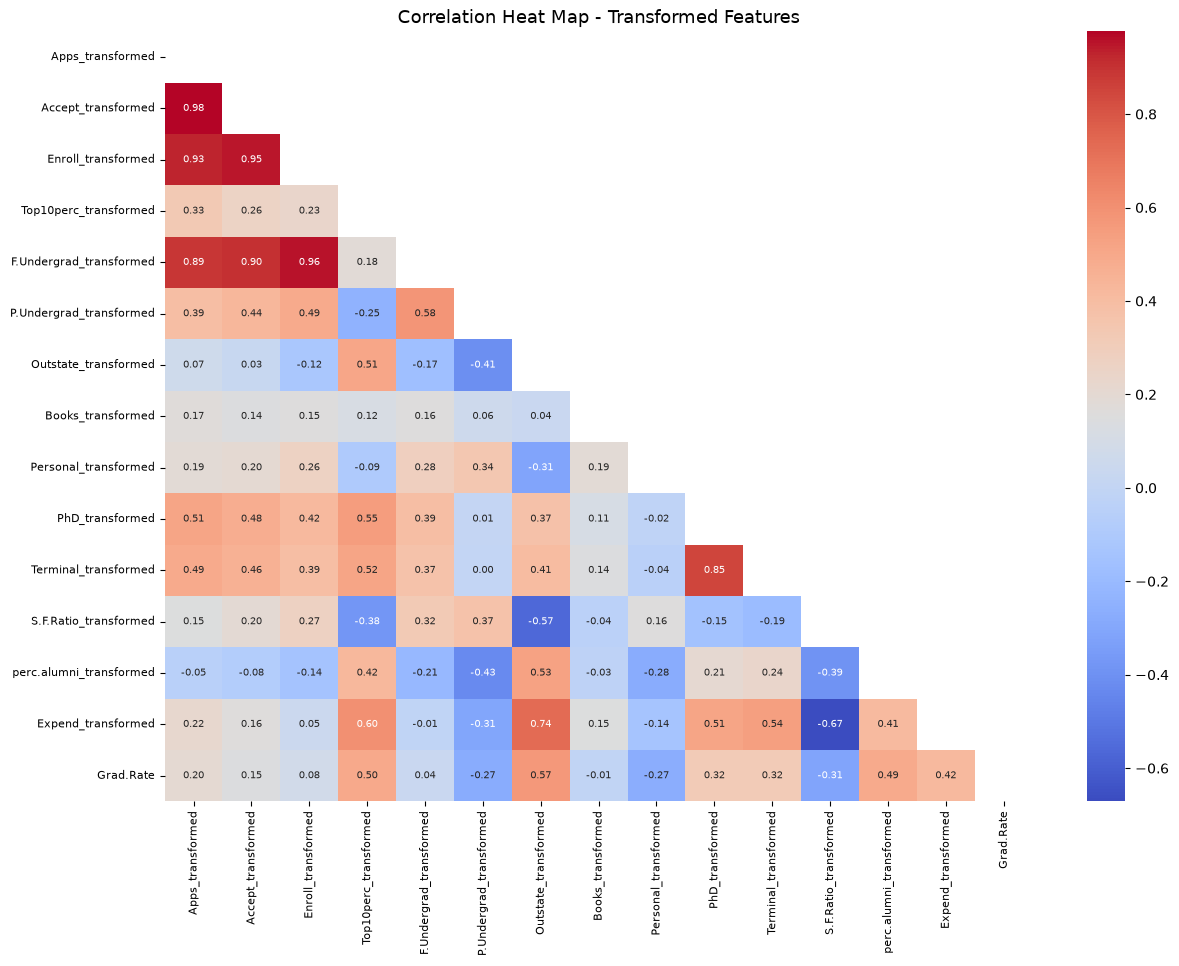

In [165]:
# Your code here

# 2. Heatmap of the transformed columns (before scaling)
transformed_cols = [col for col in df.columns if col.endswith('_transformed')] + ['Grad.Rate']

corr_transformed = df[transformed_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_transformed, annot=True, mask=np.triu(corr_transformed), annot_kws={"size": 7}, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heat Map - Transformed Features', size=13)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.show()

In [166]:
# 1. Define your target column and correlation threshold
target = 'Grad.Rate'  # Replace with your target column name if different
threshold = 0.8

# 2. Get absolute correlation matrix of original numeric columns from college_updated
corr = college_updated[transformed_cols].corr().abs()

# 3. Get a list of features (excluding the target column itself)
cols = [c for c in corr.columns if c != target]

to_drop = set()

# 4. Loop through every unique pair of features
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]

        # Check if the feature pair is highly correlated
        if corr.loc[col1, col2] >= threshold:
            # Check how each feature correlates with the target
            corr1 = corr.loc[col1, target]
            corr2 = corr.loc[col2, target]

            # Keep the one with higher target correlation, mark the lower one to drop
            if corr1 >= corr2:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

# 5. Print the columns you should remove
print("Columns to drop:", list(to_drop))

# 6. Drop those redundant columns from your college_updated dataframe
college_updated = college_updated.drop(columns=list(to_drop))

Columns to drop: ['Enroll_transformed', 'PhD_transformed', 'F.Undergrad_transformed', 'Accept_transformed']


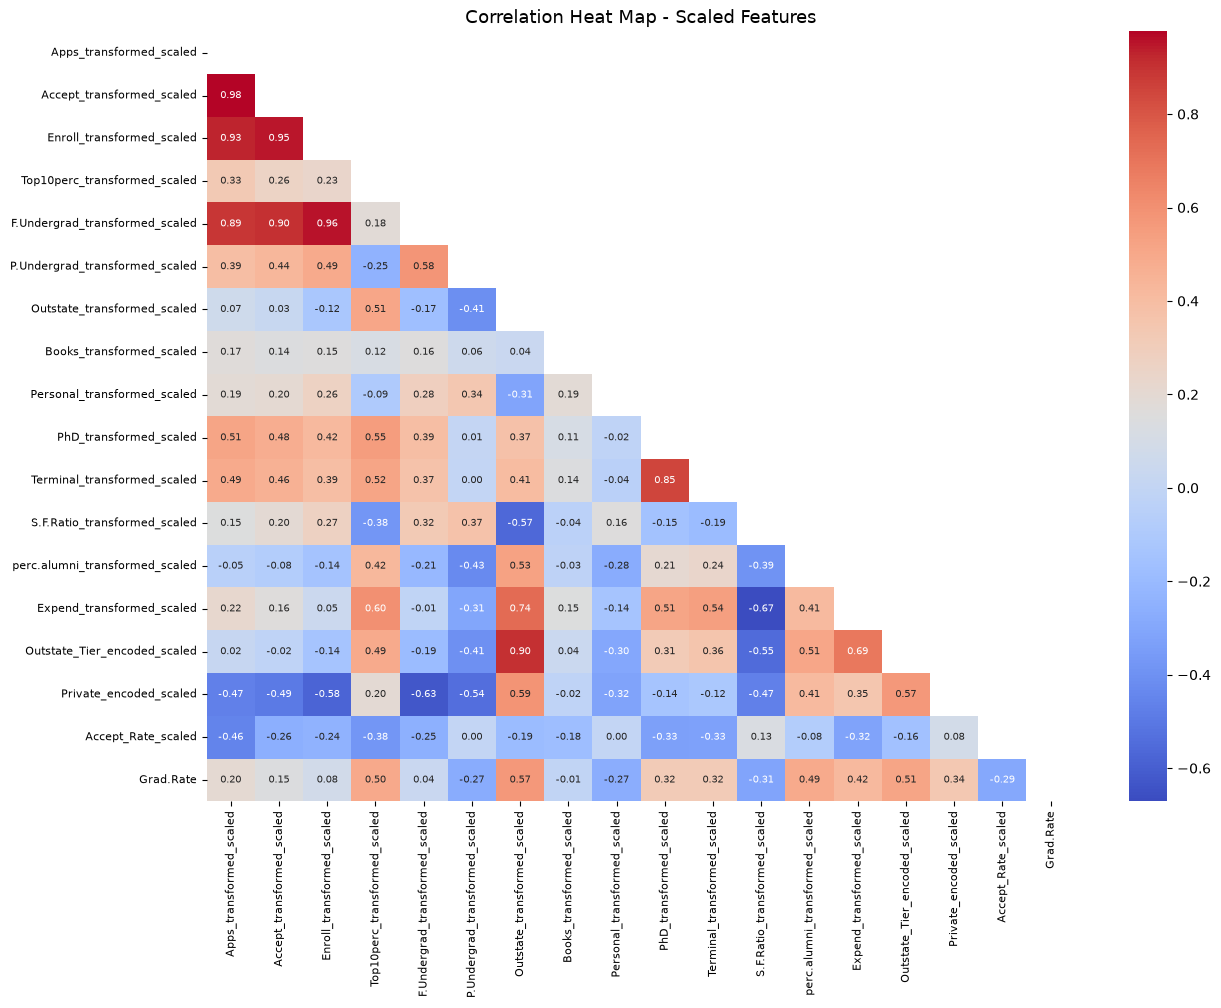

In [167]:
# Your code here

# 3. Heatmap of the scaled columns (final versions used for the model)
scaled_cols = [col for col in df.columns if col.endswith('_scaled')] + ['Grad.Rate']

corr_scaled = df[scaled_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_scaled, annot=True, mask=np.triu(corr_scaled), annot_kws={"size": 7}, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heat Map - Scaled Features', size=13)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.show()

In [168]:
# 1. Define your target column and correlation threshold
target = 'Grad.Rate'  # Replace with your target column name if different
threshold = 0.8

# 2. Get absolute correlation matrix of original numeric columns from college_updated
corr = college_updated[scaled_cols].corr().abs()

# 3. Get a list of features (excluding the target column itself)
cols = [c for c in corr.columns if c != target]

to_drop = set()

# 4. Loop through every unique pair of features
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]

        # Check if the feature pair is highly correlated
        if corr.loc[col1, col2] >= threshold:
            # Check how each feature correlates with the target
            corr1 = corr.loc[col1, target]
            corr2 = corr.loc[col2, target]

            # Keep the one with higher target correlation, mark the lower one to drop
            if corr1 >= corr2:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

# 5. Print the columns you should remove
print("Columns to drop:", list(to_drop))

# 6. Drop those redundant columns from your college_updated dataframe
college_updated = college_updated.drop(columns=list(to_drop))

Columns to drop: ['Accept_transformed_scaled', 'PhD_transformed_scaled', 'Outstate_Tier_encoded_scaled', 'F.Undergrad_transformed_scaled', 'Enroll_transformed_scaled']


In [169]:
college_updated.columns

Index(['College', 'Private', 'Apps', 'Top10perc', 'P.Undergrad', 'Outstate',
       'Room.Board', 'Books', 'Personal', 'PhD', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate', 'Apps_transformed', 'Top10perc_transformed',
       'P.Undergrad_transformed', 'Outstate_transformed', 'Books_transformed',
       'Personal_transformed', 'Terminal_transformed', 'S.F.Ratio_transformed',
       'perc.alumni_transformed', 'Expend_transformed', 'Accept_Rate',
       'Outstate_Tier', 'Outstate_Tier_encoded', 'Private_encoded',
       'Apps_transformed_scaled', 'Top10perc_transformed_scaled',
       'P.Undergrad_transformed_scaled', 'Outstate_transformed_scaled',
       'Books_transformed_scaled', 'Personal_transformed_scaled',
       'Terminal_transformed_scaled', 'S.F.Ratio_transformed_scaled',
       'perc.alumni_transformed_scaled', 'Expend_transformed_scaled',
       'Private_encoded_scaled', 'Accept_Rate_scaled'],
      dtype='str')

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [170]:
# Your code here

# untransformed predictors: original numeric columns (excluding target and non-numeric)
untrans_cols = ['Apps', 'Top10perc', 'P.Undergrad', 'Outstate', 'Room.Board',
                'Books', 'Personal', 'PhD', 'S.F.Ratio', 'perc.alumni', 'Expend']


# transformed/scaled predictors: the _scaled versions plus encoded features
trans_cols_final = ['Apps_transformed_scaled', 'Top10perc_transformed_scaled',
                     'P.Undergrad_transformed_scaled', 'Outstate_transformed_scaled',
                     'Books_transformed_scaled', 'Personal_transformed_scaled',
                     'Terminal_transformed_scaled', 'S.F.Ratio_transformed_scaled',
                     'perc.alumni_transformed_scaled', 'Expend_transformed_scaled',
                     'Private_encoded_scaled', 'Accept_Rate_scaled']

y = college_updated['Grad.Rate']

# 1. split untransformed predictors first
X_train_untrans, X_test_untrans, y_train, y_test = train_test_split(
    college_updated[untrans_cols], y, test_size=0.2, random_state=1
)

# 2. split transformed predictors with the SAME random_state, so rows match
X_train_trans, X_test_trans, _, _ = train_test_split(
    college_updated[trans_cols_final], y, test_size=0.2, random_state=1
)

# 3. scale the untransformed predictors: fit on train, transform on test
ss_untrans = StandardScaler()
X_train_untrans_std = ss_untrans.fit_transform(X_train_untrans)
X_test_untrans_std = ss_untrans.transform(X_test_untrans)





#### 15. Fit a linear regression using the raw predictors


In [171]:
untrans_predictors = []

# Your code here 
untrans_predictors = untrans_cols

model_untrans = LinearRegression()
model_untrans.fit(X_train_untrans_std, y_train)

print('Train R2:', model_untrans.score(X_train_untrans_std, y_train))
print('Test R2:', model_untrans.score(X_test_untrans_std, y_test))

Train R2: 0.45193934475036257
Test R2: 0.46828746200706595


#### 16. Fit the same model using the log-transformed predictors

In [172]:
trans_predictors = []

# Your code here 
trans_predictors = trans_cols_final

model_trans = LinearRegression()
model_trans.fit(X_train_trans, y_train)

print('Train R2:', model_trans.score(X_train_trans, y_train))
print('Test R2:', model_trans.score(X_test_trans, y_test))

Train R2: 0.46863945823457487
Test R2: 0.48513472451325856


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [173]:
# Your code here 
print('Untransformed Model:')
print('Train R2:', model_untrans.score(X_train_untrans_std, y_train))
print('Test R2:', model_untrans.score(X_test_untrans_std, y_test))

print()

print('Transformed Model:')
print('Train R2:', model_trans.score(X_train_trans, y_train))
print('Test R2:', model_trans.score(X_test_trans, y_test))

Untransformed Model:
Train R2: 0.45193934475036257
Test R2: 0.46828746200706595

Transformed Model:
Train R2: 0.46863945823457487
Test R2: 0.48513472451325856


>Yes, slightly. The transformed model scored higher on both train (0.469 vs 0.452) and test (0.485 vs 0.468) R², showing the transformation modestly improved the fit.

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [174]:
# Your code here 
college_updated.to_csv('college_transformed.csv', index=False)